**Author:** Biswajit Jana  
**Date:** April 29, 2026  

# Pleiades proper-motion dispersion after measurement errors

**Date:** 2026-07-31  
**Scientific question:** How much proper-motion scatter remains after subtracting the reported Gaia uncertainties?  
**Preserved source:** `../2026-07-31-gaia-pleiades-membership-distance/pleiades_members.csv`

The observed width of a cluster's proper-motion clump combines internal motion,
      binaries, contamination, perspective effects, and measurement error. We estimate the
      intrinsic component by subtracting the mean squared formal error from the robust observed
      variance in each coordinate, then convert milliarcseconds per year to kilometres per
      second using the mean parallax.

      This scalar deconvolution ignores covariance and spatial perspective, so it is a diagnostic
      rather than a final velocity-dispersion measurement. Restricting to brighter stars checks
      whether faint-source uncertainty dominates.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
members=pd.read_csv("../2026-07-31-gaia-pleiades-membership-distance/pleiades_members.csv"); members=members[members.member.astype(bool)].copy()
members=members.dropna(subset=["parallax","parallax_error","pmra","pmdec","phot_g_mean_mag","bp_rp","ruwe"])
members["abs_g"]=members.phot_g_mean_mag+5*np.log10(members.parallax)-10
print(f"Preserved astrometric members: {len(members)}")

Preserved astrometric members: 609


In [3]:
def robust_sigma(x): return 1.4826*np.median(np.abs(x-np.median(x)))
sx,sy=robust_sigma(members.pmra),robust_sigma(members.pmdec); ex=np.sqrt(np.mean(members.pmra_error**2)); ey=np.sqrt(np.mean(members.pmdec_error**2)); ix=np.sqrt(max(0,sx*sx-ex*ex)); iy=np.sqrt(max(0,sy*sy-ey*ey)); par=members.parallax.mean(); vx=4.74047*ix/par; vy=4.74047*iy/par
print(f"observed σ=({sx:.3f},{sy:.3f}) mas/yr; deconvolved=({ix:.3f},{iy:.3f}); velocity=({vx:.3f},{vy:.3f}) km/s")

observed σ=(1.009,1.150) mas/yr; deconvolved=(1.002,1.147); velocity=(0.645,0.739) km/s


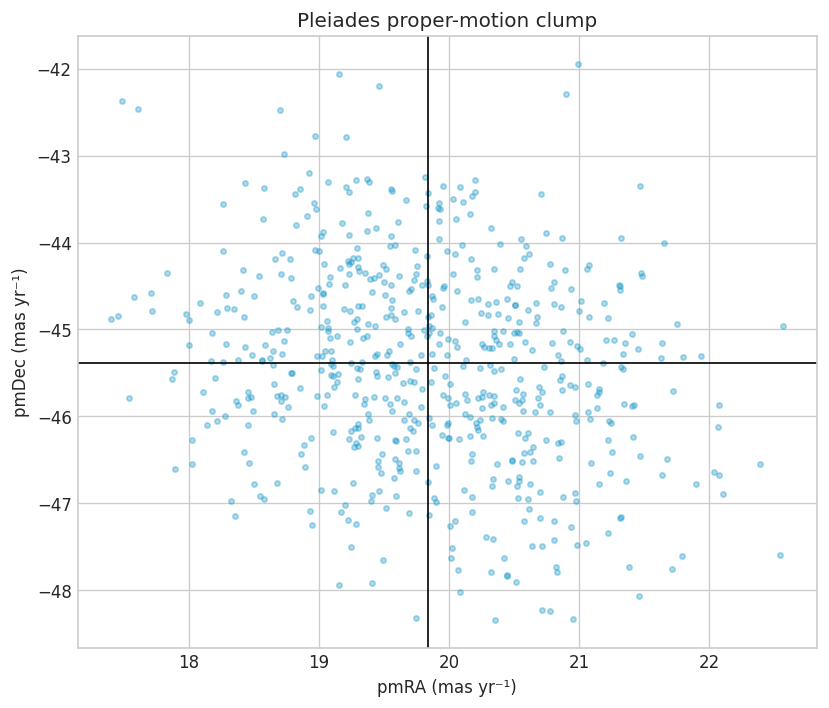

In [4]:
fig,ax=plt.subplots(figsize=(7,6)); ax.scatter(members.pmra,members.pmdec,s=10,alpha=.35,color=COLORS["blue"]); ax.axvline(members.pmra.median(),color="k",lw=1); ax.axhline(members.pmdec.median(),color="k",lw=1); ax.set(xlabel="pmRA (mas yr⁻¹)",ylabel="pmDec (mas yr⁻¹)",title="Pleiades proper-motion clump"); fig.tight_layout(); fig.savefig("pleiades_pm_dispersion.png",dpi=180); plt.show()

In [5]:
bright=members[members.phot_g_mean_mag<15]; sx_b,sy_b=robust_sigma(bright.pmra),robust_sigma(bright.pmdec); ex_b=np.sqrt(np.mean(bright.pmra_error**2)); ey_b=np.sqrt(np.mean(bright.pmdec_error**2)); ix_b=np.sqrt(max(0,sx_b*sx_b-ex_b*ex_b)); iy_b=np.sqrt(max(0,sy_b*sy_b-ey_b*ey_b)); print(f"G<15 deconvolved σ=({ix_b:.3f},{iy_b:.3f}) mas/yr, N={len(bright)}")

G<15 deconvolved σ=(0.798,1.045) mas/yr, N=207


In [6]:
result={"id":"2026-07-31-pleiades-proper-motion-dispersion","title":"Pleiades proper-motion dispersion","archive":"Gaia DR3","date":"2026-07-31","question":"What scatter remains after formal-error subtraction?","sample_size":int(len(members)),"results":[f"deconvolved σRA {ix:.3f} mas/yr",f"deconvolved σDec {iy:.3f} mas/yr",f"velocity equivalents {vx:.3f}, {vy:.3f} km/s"],"validation":"The calculation is repeated for G<15 members.","notebook":"gaia/2026-07-31-pleiades-proper-motion-dispersion/notebook.ipynb","hero":"gaia/2026-07-31-pleiades-proper-motion-dispersion/pleiades_pm_dispersion.png","tags":["Pleiades","proper motion","kinematics"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['deconvolved σRA 1.002 mas/yr', 'deconvolved σDec 1.147 mas/yr', 'velocity equivalents 0.645, 0.739 km/s']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- ESA Gaia Archive: https://gea.esac.esa.int/archive/
- Gaia Collaboration (2023), Gaia Data Release 3 summary: https://doi.org/10.1051/0004-6361/202243940
- Lindegren et al. (2021), Gaia EDR3 astrometric solution: https://arxiv.org/abs/2012.03380
- Gaia Collaboration (2018), cluster kinematics and dynamics: https://arxiv.org/abs/1804.09378

Formal catalogue errors do not include every spatially correlated systematic.
The deconvolved cluster widths are therefore conservative diagnostics.